In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from typing import Optional
import matplotlib
from matplotlib.cm import PRGn, YlGnBu
from plottable import ColumnDefinition, Table
from plottable.cmap import normed_cmap
from plottable.plots import bar

In [ ]:
import os

In [ ]:
matplotlib.rcParams['pdf.fonttype'] = 42

# Define functions

In [ ]:
class MetricPlotter:
    """Class to plot benchmarking metrics from pre-computed data.

    Parameters
    ----------
    results_df
        DataFrame containing the metrics results. Columns are methods, rows are metrics.
    """

    def __init__(self, results_df: pd.DataFrame):
        self.results_df = results_df.copy()

    def get_scaled_results(self, min_max_scale: bool = True) -> pd.DataFrame:
        df = self.results_df.transpose()

        if min_max_scale:
            scaler = MinMaxScaler()
            df = pd.DataFrame(
                scaler.fit_transform(df),
                columns=df.columns,
                index=df.index,
            )

        df["Total"] = df.mean(axis=1)
        return df

    def plot_results(self, min_max_scale: bool = True, show: bool = True, save_path: Optional[str] = None, fig_size = None):
        df = self.get_scaled_results(min_max_scale=min_max_scale)
        plot_df = df.sort_values(by="Total", ascending=False).astype(float)
        plot_df["Method"] = plot_df.index

        cmap_fn = lambda col_data: normed_cmap(col_data, cmap=PRGn, num_stds=2.5)

        column_definitions = [
            ColumnDefinition("Method", width=1.5, textprops={"ha": "left", "weight": "bold"}),
        ] + [
            ColumnDefinition(
                col,
                title=col.replace(" ", "\n", 1),
                width=1,
                textprops={"ha": "center", "bbox": {"boxstyle": "circle", "pad": 0.25}},
                cmap=cmap_fn(plot_df[col]),
                formatter="{:.2f}",
            )
            for col in plot_df.columns if col not in ["Method", "Total"]
        ] + [
            ColumnDefinition(
                "Total",
                width=1,
                title="Total",
                plot_fn=bar,
                plot_kw={
                    "cmap": YlGnBu,
                    "plot_bg_bar": False,
                    "annotate": True,
                    "height": 0.9,
                    "formatter": "{:.2f}",
                },
                border="left",
            )
        ]

        with matplotlib.rc_context({"svg.fonttype": "none"}):
            if fig_size is None:
                fig_size = (len(plot_df.columns) * 1.25, 3 + 0.3 * len(plot_df))
            fig, ax = plt.subplots(figsize=fig_size)
            tab = Table(
                plot_df,
                cell_kw={"linewidth": 0, "edgecolor": "k"},
                column_definitions=column_definitions,
                ax=ax,
                row_dividers=True,
                footer_divider=True,
                textprops={"fontsize": 10, "ha": "center"},
                row_divider_kw={"linewidth": 1, "linestyle": (0, (1, 5))},
                col_label_divider_kw={"linewidth": 1, "linestyle": "-"},
                column_border_kw={"linewidth": 1, "linestyle": "-"},
                index_col="Method",
            ).autoset_fontcolors(colnames=plot_df.columns)

        if save_path:
            fig.savefig(save_path, facecolor=ax.get_facecolor(), dpi=300)

        if show:
            plt.show()

        plt.close(fig)


# Load data

In [5]:
holder = []

for model in ['GPformer', 'expimap', 'spectra']:
    for run in ['run_1', 'run_2', 'run_3']:
        dirpath = os.path.join(model, run, 'logistic_regression')
        
        # find all csv files in filepath
        for filename in os.listdir(dirpath):
            # Check if the file has a .csv extension
            if filename.endswith('.csv'):
                if 'celltype_id' in filename:
                    continue
                if 'stage_granular' in filename:
                    continue
                if 'disease_binary' in filename:
                    continue
                if 'Endometrial_pathology' in filename:
                    continue
                
                file_path = os.path.join(dirpath, filename)

                label_type, gp = filename.replace('.csv', '').replace('from_', '').split('id_')

                df = pd.read_csv(file_path)
                df['model'] = model
                df['label_type'] = label_type
                df['gp'] = gp
                df['run'] = run

                holder.append(df)

dataframes = pd.concat(holder)

In [ ]:
dataframes['model'] = dataframes['model'].replace(
    {'expimap' : 'Expimap',
     'spectra' : 'Spectra'
    }
)

In [7]:
dataframes.head()

,output_class,metric,value,accuracy,model,label_type,gp,run
0,Secretory,precision,0.996170,0.966158,GPformer,ct_broad_,WNT,run_1
1,Secretory,recall,0.966158,0.966158,GPformer,ct_broad_,WNT,run_1
2,Secretory,f1-score,0.980934,0.966158,GPformer,ct_broad_,WNT,run_1
3,Secretory,support,4846.000000,0.966158,GPformer,ct_broad_,WNT,run_1
4,Ciliated,precision,0.758112,0.966158,GPformer,ct_broad_,WNT,run_1


# Make table

In [ ]:
dataframes['label'] = dataframes['label_type'] + dataframes['output_class']

In [ ]:
df1 = dataframes[dataframes['metric'] == 'f1-score'][['model', 'label', 'value']]

In [10]:
df1.head()

,model,label,value
2,GPformer,ct_broad_Secretory,0.980934
6,GPformer,ct_broad_Ciliated,0.849587
2,GPformer,stage_Proliferative,0.860672
6,GPformer,stage_Secretory,0.877990
2,GPformer,ct_broad_Secretory,0.988780


In [ ]:
plotting_df = df1.pivot_table(
    index='model', 
    columns='label', 
    values='value', 
    aggfunc='mean'  
)

In [19]:
# Calculate mean and std for each (model, label) combination
summary_stats = df1.groupby(['model', 'label'])['value'].agg(['mean', 'std']).reset_index()

# Round to 3 decimals
summary_stats['mean'] = summary_stats['mean'].round(3)
summary_stats['std'] = summary_stats['std'].round(3)

summary_stats['label'] = summary_stats['label'].str.replace('ct_broad', 'celltypebroad ', regex=False)
summary_stats['task'], summary_stats['label_name'] = zip(*summary_stats['label'].apply(lambda x: x.split('_', -1)))
summary_stats['task'] = summary_stats['task'].replace(
    {
        'celltypebroad ': 'broad cell type',
        'stage' : 'binary menstrual stage',
    }
)

summary_stats['model'] = summary_stats['model'].replace(
    {'GPformer' : 'Tripso'}
)

# Save to CSV
summary_stats = summary_stats[['model', 'task', 'label_name', 'mean', 'std']]

# Sort by model and label for better readability
summary_stats = summary_stats.sort_values(['task', 'model'])

summary_stats.to_csv('endometrium_summary_statistics.csv', index=False)

print(f"Summary statistics saved to 'endometrium_summary_statistics.csv'")
print(f"\nPreview:")
print(summary_stats.head(10))

Summary statistics saved to 'endometrium_summary_statistics.csv'

Preview:
      model                    task     label_name   mean    std
2   Expimap  binary menstrual stage  Proliferative  0.618  0.005
3   Expimap  binary menstrual stage      Secretory  0.642  0.005
10  Spectra  binary menstrual stage  Proliferative  0.499  0.021
11  Spectra  binary menstrual stage      Secretory  0.558  0.048
6    Tripso  binary menstrual stage  Proliferative  0.874  0.018
7    Tripso  binary menstrual stage      Secretory  0.891  0.017
0   Expimap         broad cell type       Ciliated  0.286  0.002
1   Expimap         broad cell type      Secretory  0.759  0.006
8   Spectra         broad cell type       Ciliated  0.198  0.019
9   Spectra         broad cell type      Secretory  0.728  0.038


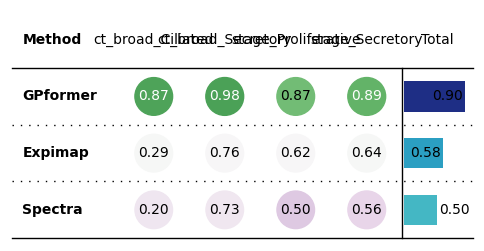

In [13]:
# plotting_df is a dataframe where the columns represent metric names, 
# the index is different methods, filled with the relevant values

plotter = MetricPlotter(results_df=plotting_df.T)
plotter.plot_results(min_max_scale=False, show=True, 
                     # save_path = 'gp_benchmark_narrow.pdf',
                    fig_size = (6,3))
